**Neural Networks are Math Expressions:** A neural network, despite the biological naming, is ultimately just a massive mathematical equation. Training it means evaluating derivatives to figure out how to tweak the inputs (weights) to minimize the output (loss).

**The Value Object:** Standard Python numbers do not remember how they were created. Wrapping floats in a custom Value class allows the engine to intercept mathematical operations (like +, *) and record their history.

**Building the Graph (DAG):** As mathematical operations are performed on Value objects, micrograd dynamically builds a Directed Acyclic Graph (similar to syntax/parse tree) in the background. It remembers exactly which variables combined to create new variables.

**Forward Pass:** The standard evaluation of the mathematical expression. It calculates the final numerical output (e.g., g.data) moving from the inputs to the final node.

**Backward Pass (.backward())**: A reverse-topological traversal of the graph that applies the Chain Rule from calculus. It moves from the final output back down to the leaf nodes.

**The Gradient (.grad):** The numerical derivative calculated during the backward pass. It tells you exactly how much the final output g would change if you adjusted a specific input variable (like a or b) by a tiny fraction.

**Scalars vs. Tensors:** micrograd works on individual scalars (single numbers) to keep the core calculus clear. Real frameworks like PyTorch perform the exact same backpropagation, but they operate on Tensors (n-dimensional arrays of numbers) purely to evaluate operations in parallel on GPUs.

In [350]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [351]:
def f(x):
  return 3*x**2 - 4*x + 5 #3x^2 - 4x +5 (parabolic equation)

In [352]:
f(4.0)

37.0

In [353]:
f(3.0)

20.0

In [354]:
xs=np.arange(-5,5,0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

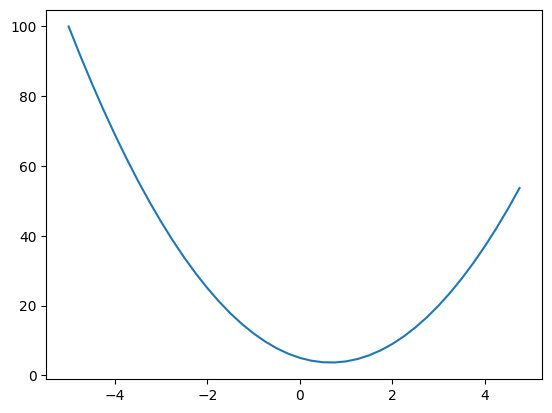

In [355]:
ys=f(xs)
plt.plot(xs,ys) #a parabola

if we differentiate a parabolic equation we get the form $$Y=Mx+C$$ (a straight line)

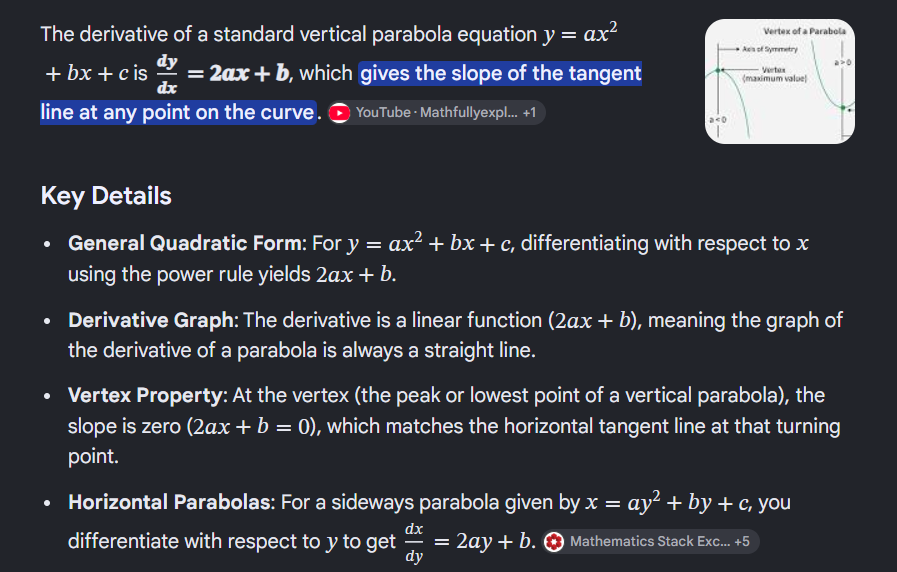

In [356]:
h=0.001
x=3.0
f(x+h)

20.014003000000002

f(x) value responds positive when value of h is increased

In [357]:
(f(x+h)-f(x))/h #this is the slop of the numerical approximation of it

14.00300000000243

In [358]:
h=0.000000000000000001
x=3.0
(f(x+h)-f(x))/h

0.0

Cell number 16 returns 0.0 because of limitations in floating-point precision. When h is set to an extremely small value like 1e-18, adding h to x=3.0 does not actually change the value of x in standard floating-point arithmetic. This means f(x+h) becomes effectively the same as f(x), making the numerator (f(x+h) - f(x)) equal to zero. Dividing zero by h then results in 0.0.

In [359]:
h=0.000001
x=-3.0
(f(x+h)-f(x))/h

-21.999997002808414

The derivative of `f(x) = 3x^2 - 4x + 5` is `f'(x) = 6x - 4`.

To find the x-coordinate where the slope is 0, we set the derivative to 0:

`6x - 4 = 0`
`6x = 4`
`x = 4/6`
`x = 2/3`

In [360]:
# Calculate the x-coordinate where the slope is 0
x_at_zero_slope = 4/6
print(f"The x-coordinate where the slope is 0 (the vertex of the parabola) is: {x_at_zero_slope}")

The x-coordinate where the slope is 0 (the vertex of the parabola) is: 0.6666666666666666


In [361]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [362]:
h=0.0001
#inputs
a=2.0
b=-3.0
c=10.0

d1=a*b+c
a+=h
d2=a*b+c #here a*b will actually decrease the value of d2
print("d1=",d1)
print("d2=",d2)
print("slope=",(d2-d1)/h)

d1= 4.0
d2= 3.999699999999999
slope= -3.000000000010772


In [363]:
class value:
  def __init__(self,data,_children=(),_op='', label=''):
    self.data=data
    self.grad=0.0
    self._prev=set(_children)
    self._op=_op
    self.label=label

  def __repr__(self):
    return f"value(data={self.data})"

  def __add__(self,other):
    other = other if isinstance(other, value) else value(other)
    out = value(self.data+other.data,(self,other),'+')

    def _backward():
      self.grad += out.grad
      other.grad += out.grad
    out._backward = _backward
    return out

  def __mul__(self,other):
    other = other if isinstance(other, value) else value(other)
    out = value(self.data*other.data,(self,other),'*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward
    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __radd__(self, other): # other + self
    return self + other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = value(t, (self,), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      if hasattr(node, '_backward'):
        node._backward()

Cell 22 defines a Python class named `value`.

*   **`__init__(self, data)`**: This is the constructor method. When you create a new `value` object (e.g., `my_value = value(10)`), this method is called. It initializes the `data` attribute of the object with the value passed to it.
*   **`__repr__(self)`**: This method defines the "official" string representation of an object. When you print a `value` object or inspect it in the notebook, this method is called to return a string. In this case, it returns a string like `"value(data=X)"` where X is the actual data stored in the object. This is useful for debugging and understanding the object's state.

In [364]:
a=value(2.0, label='a')
b=value(-3.0,label='b')
c=value(10.0,label='c')
e=a*b; e.label='e'
d=e+c; d.label='d'

f=value(-2.0,label='f')
L=d*f; L.label='L' #output of the graph
d
print(a,b)
a+b #internally call a.__add___(b)

value(data=2.0) value(data=-3.0)


value(data=-1.0)

In [365]:
a*b

value(data=-6.0)

In [366]:
d = a * b + c # c is already a value object
d

value(data=4.0)

In [367]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

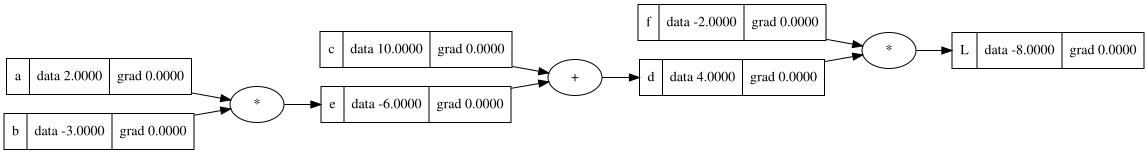

In [368]:
draw_dot(L)


In [369]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-8.0


# So let's quickly recap
what we've done so far we are able to build out mathematical expressions using only + and *.

So far they are scalar valued along the way and we can do this forward pass and build out a mathematical expression so we have multiple inputs here a b c and f going into a mathematical expression that produces a single output L and this here is visualizing the forward pass so the output of the forward pass is -8.

In [370]:
# Re-initialize the graph to ensure all nodes have the latest 'value' class definition
# and that all gradients are reset to 0 before backpropagation.
a=value(2.0, label='a')
b=value(-3.0,label='b')
c=value(10.0,label='c')
e=a*b; e.label='e'
d=e+c; d.label='d'
f=value(-2.0,label='f')
L=d*f; L.label='L'

In [371]:
# Perform the backward pass to compute gradients
L.backward()

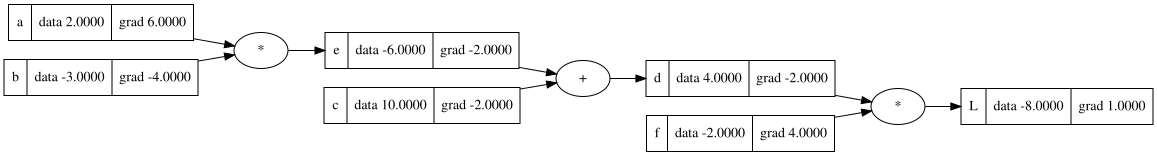

In [372]:
# Visualize the graph with computed gradients
draw_dot(L)

In [373]:
def lol():
  h=0.0001 # Changed h to a small non-zero value
  a=value(2.0, label='a')
  b=value(-3.0,label='b')
  c=value(10.0,label='c')
  e=a*b; e.label='e'
  d=e+c; d.label='d'
  f=value(-2.0,label='f')
  L=d*f; L.label='L'
  L1=L

  a=value(2.0+h, label='a')
  b=value(-3.0,label='b')
  c=value(10.0,label='c')
  e=a*b; e.label='e'
  d=e+c; d.label='d'
  f=value(-2.0,label='f')
  L=d*f; L.label='L'
  L2=L

  print((L2-L1)/h) #rise over run


lol()

value(data=6.000000000021544)


In [374]:
def lol():
  h=0.0001 # Changed h to a small non-zero value
  a=value(2.0, label='a')
  b=value(-3.0,label='b')
  c=value(10.0,label='c')
  e=a*b; e.label='e'
  d=e+c; d.label='d'
  f=value(-2.0,label='f')
  L=d*f; L.label='L'
  L1=L

  a=value(2.0+h, label='a')
  b=value(-3.0,label='b')
  c=value(10.0,label='c')
  e=a*b; e.label='e'
  d=e+c; d.label='d'
  f=value(-2.0,label='f')
  L=d*f; L.label='L'
  L2=L

  print((L2-L1)/h) #rise over run


lol()

value(data=6.000000000021544)


### Mathematical Explanation of Gradient Calculation (Backpropagation)

The core idea behind backpropagation is the **Chain Rule** from calculus. For our expression `L = d * f`, where `d = e + c` and `e = a * b`, we want to find how much `L` changes with respect to its inputs (`a`, `b`, `c`, `f`). This is represented by their gradients (`L.grad`, `a.grad`, `b.grad`, `c.grad`, `f.grad`).

1.  **Start with the output (`L`):** The gradient of `L` with respect to itself is always 1.0. So, `L.grad = 1.0`.

2.  **Propagate `L.grad` to its immediate children (`d` and `f`):**
    *   `L = d * f`
    *   `dL/dd = f` (partial derivative of L with respect to d)
    *   `dL/df = d` (partial derivative of L with respect to f)
    *   Therefore, `d.grad = L.grad * (dL/dd) = L.grad * f.data`
    *   And `f.grad = L.grad * (dL/df) = L.grad * d.data`

3.  **Propagate `d.grad` to its immediate children (`e` and `c`):**
    *   `d = e + c`
    *   `dd/de = 1` (partial derivative of d with respect to e)
    *   `dd/dc = 1` (partial derivative of d with respect to c)
    *   Therefore, `e.grad = d.grad * (dd/de) = d.grad * 1`
    *   And `c.grad = d.grad * (dd/dc) = d.grad * 1`

4.  **Propagate `e.grad` to its immediate children (`a` and `b`):**
    *   `e = a * b`
    *   `de/da = b` (partial derivative of e with respect to a)
    *   `de/db = a` (partial derivative of e with respect to b)
    *   Therefore, `a.grad = e.grad * (de/da) = e.grad * b.data`
    *   And `b.grad = e.grad * (de/db) = e.grad * a.data`

This process continues backward through the graph until all leaf nodes have their gradients computed. Each node's `grad` accumulates the contributions from all paths leading to the final output.

### Coding Explanation: `_backward` methods for Operations

The `value` class implements the chain rule by attaching a small `_backward` function to each `value` object that is the result of an operation. This `_backward` function knows how to compute the gradient contributions for its immediate children (the inputs to that operation) based on its own `out.grad`.

Let's look at the `_backward` implementations for the operations you've defined:

*   **`__add__(self, other)` (Addition):**
    ```python
    def _backward():
      self.grad += out.grad # dL/d(self) = dL/d(out) * d(out)/d(self) = out.grad * 1
      other.grad += out.grad # dL/d(other) = dL/d(out) * d(out)/d(other) = out.grad * 1
    out._backward = _backward
    ```
    If `out = self + other`, then `d(out)/d(self) = 1` and `d(out)/d(other) = 1`. So, `self.grad` and `other.grad` each receive `out.grad` (the gradient flowing into `out`). The `+=` is crucial for accumulating gradients from multiple paths.

*   **`__mul__(self, other)` (Multiplication):**
    ```python
    def _backward():
      self.grad += other.data * out.grad # dL/d(self) = dL/d(out) * d(out)/d(self) = out.grad * other.data
      other.grad += self.data * out.grad # dL/d(other) = dL/d(out) * d(out)/d(other) = out.grad * self.data
    out._backward = _backward
    ```
    If `out = self * other`, then `d(out)/d(self) = other` and `d(out)/d(other) = self`. So, `self.grad` gets `other.data * out.grad`, and `other.grad` gets `self.data * out.grad`.

*   **`__sub__(self, other)` (Subtraction):**
    ```python
    def _backward():
      self.grad += out.grad # dL/d(self) = dL/d(out) * d(out)/d(self) = out.grad * 1
      other.grad -= out.grad # dL/d(other) = dL/d(out) * d(out)/d(other) = out.grad * (-1)
    out._backward = _backward
    ```
    If `out = self - other`, then `d(out)/d(self) = 1` and `d(out)/d(other) = -1`. Hence, `other.grad` subtracts `out.grad`.

*   **`__truediv__(self, other)` (Division by scalar):**
    ```python
    def _backward():
      self.grad += (1/other) * out.grad # dL/d(self) = dL/d(out) * d(out)/d(self) = out.grad * (1/other)
    out._backward = _backward
    ```
    If `out = self / other` (where `other` is a scalar), then `d(out)/d(self) = 1/other`. So, `self.grad` gets `(1/other) * out.grad`.

### Coding Explanation: The Main `backward()` Method

The main `backward()` method orchestrates the entire backpropagation process. It performs the following steps:

1.  **Topological Sort (`build_topo`):**
    *   The `build_topo` function performs a Depth-First Search (DFS) on the computational graph, starting from the `self` node (the output of the expression, `L` in our example). It recursively visits all parents (`_prev`) of a node.
    *   Nodes are added to the `topo` list *after* all their children have been visited. This ensures that `topo` contains the nodes in **reverse topological order**. This order is critical because we need to compute the gradient for a node *before* we can use that gradient to compute the gradients of its children (which are its inputs).

2.  **Initialize `self.grad = 1.0`:**
    *   The gradient of the output (`L`) with respect to itself is defined as 1.0. This is the starting point for propagating gradients backward.

3.  **Iterate and Propagate:**
    *   The code then iterates through the `topo` list in `reversed(topo)` order. This means it starts from the output node (`L`), then its immediate parents, and so on, moving backward through the graph.
    *   For each `node` in this reverse order, it checks if the `node` has a `_backward` function (which it will if it was the result of an operation).
    *   If `_backward` exists, it calls `node._backward()`. This executes the specific gradient calculation logic for that operation, pushing the gradient from `node.grad` to its inputs (`self.grad` and `other.grad` in the `_backward` context).

By following this sequence, each `_backward` call correctly contributes to the gradients of the input `value` objects, accumulating them where multiple paths exist, until all leaf nodes (`a`, `b`, `c`, `f`) have their final gradients computed.

After `L.backward()` is called, the `draw_dot(L)` function then visualizes this entire graph, now displaying the `data` and the newly calculated `grad` for each `value` node, allowing you to see the derivatives at every step of the computation.

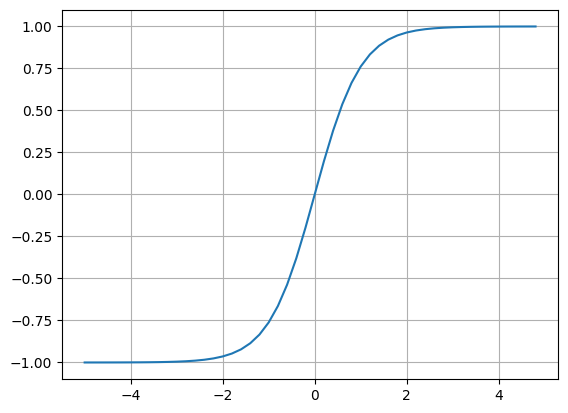

In [375]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [376]:
# inputs x1,x2
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')
# weights w1,w2
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')
# bias of the neuron
b = value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

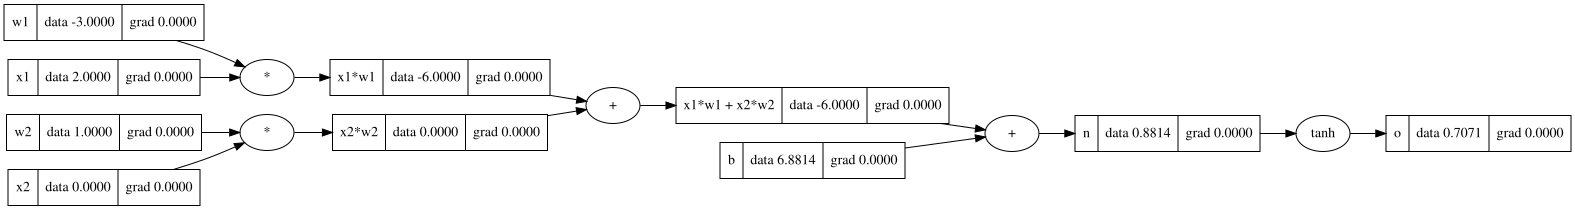

In [377]:
draw_dot(o)

In [378]:
# Calling the backward function on the output node 'o' to compute all gradients
o.grad=1.0
o.backward()

Explanation of the Computational Graph Visualization
When draw_dot(o) is executed, it produces a visual representation of your entire computational graph as an image (likely an SVG) directly in the notebook. This graph illustrates the dependencies between all your value objects, from the inputs (x1, x2, w1, w2, b) all the way to the final output (o).

Working:

Nodes: Each rectangular box in the graph represents a value object. It displays three key pieces of information:

Label: The name you assigned to the value (e.g., x1, w1, n, o).
Data: The numerical result of the forward pass calculation for that value object (e.g., x1.data, n.data).
Grad: The calculated gradient (.grad attribute) of the final output o with respect to that specific value object. These are the derivatives computed during the backpropagation step.
Operation Nodes: The smaller, usually circular or diamond-shaped nodes (e.g., *, +, tanh) represent the mathematical operations that combined value objects to create new ones. They show how intermediate results were derived.

Edges (Arrows): The arrows connect the value nodes and operation nodes, showing the flow of computation:

Arrows from value nodes to an operation node indicate that those value objects were inputs to that operation.
Arrows from an operation node to a value node indicate that the value object is the result of that operation.
Functionality:

Understanding Flow: It provides a clear, intuitive way to see the entire computation that leads from your initial inputs to your final output.

Debugging Backpropagation: This visualization is incredibly useful for debugging your backpropagation implementation. You can visually inspect the grad values at each node to confirm that they are what you expect based on the chain rule. If a gradient is unexpectedly zero, incorrect, or None, it immediately points to an issue in the _backward method for a particular operation or the backward traversal itself.

Educational Tool: It's an excellent educational tool for understanding how neural networks work at a fundamental level, demonstrating the forward pass, the operations, and critically, how gradients propagate backward through the graph to update inputs.

In essence, the graph is a powerful visual debugger and explanatory tool for your value class and its automatic differentiation capabilities.

In [379]:
o.grad=1.0

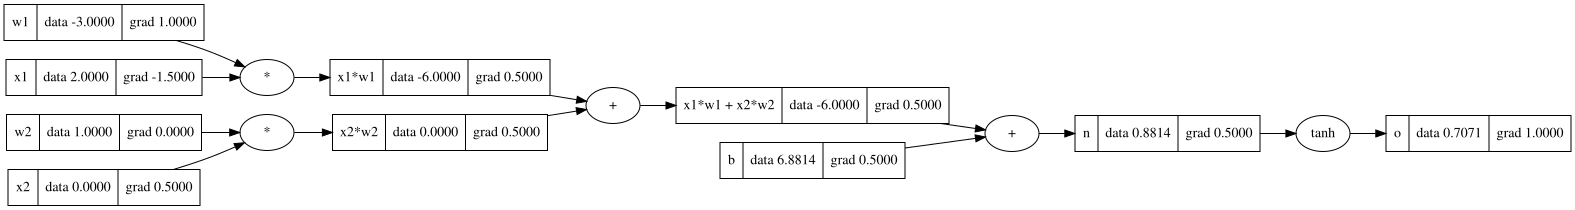

In [380]:
draw_dot(o)

In [381]:
print(f"o.data: {o.data}")
print(f"n.grad (auto): {n.grad}")
print(f"Manual calculation (1 - o.data**2): {1 - o.data**2}")
print("---")
print(f"x1.grad: {x1.grad} (Expected: w1.data * n.grad = {-3.0 * n.grad})")
print(f"w1.grad: {w1.grad} (Expected: x1.data * n.grad = {2.0 * n.grad})")

o.data: 0.7071067811865476
n.grad (auto): 0.4999999999999999
Manual calculation (1 - o.data**2): 0.4999999999999999
---
x1.grad: -1.4999999999999996 (Expected: w1.data * n.grad = -1.4999999999999996)
w1.grad: 0.9999999999999998 (Expected: x1.data * n.grad = 0.9999999999999998)


In [382]:
# Reset all gradients to zero
for v in [x1, x2, w1, w2, b, x1w1, x2w2, x1w1x2w2, n, o]:
    v.grad = 0.0

# Re-run backward
o.grad = 1.0
o.backward()

# Check values again
print(f"o.data: {o.data}")
print(f"n.grad (auto): {n.grad} (Matches manual 0.5?)")
print(f"x1.grad (auto): {x1.grad} (Matches manual -1.5?)")

o.data: 0.7071067811865476
n.grad (auto): 0.4999999999999999 (Matches manual 0.5?)
x1.grad (auto): -1.4999999999999996 (Matches manual -1.5?)


In [383]:
#o = tanh(n)
#do/dn = 1-o**2

In [384]:
1-o.data**2 # this is n.grad

0.4999999999999999

In [385]:
n.grad=0.5

In [386]:
x1w1x2w2.grad=0.5
b.grad=0.5

In [387]:
x1w1.grad=0.5
x2w2.grad=0.5

In [388]:
# '+' means the gradient value will just flow through the graph...

In [389]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [390]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

### Explanation of Gradient Formulas in Cells 44 and 46

These cells represent the manual application of the **Chain Rule** for a multiplication operation ($out = a \times b$).

#### Mathematical Rule:
For any multiplication node $out = x \times y$, the local derivatives are:
1. $\frac{\partial out}{\partial x} = y$
2. $\frac{\partial out}{\partial y} = x$

Applying the Chain Rule to find the gradient of the final output $L$ with respect to the inputs:
*   **$x.grad = \frac{\partial L}{\partial out} \times \frac{\partial out}{\partial x} = out.grad \times y.data$**
*   **$y.grad = \frac{\partial L}{\partial out} \times \frac{\partial out}{\partial y} = out.grad \times x.data$**

#### Application in your code:
*   **Cell 44 (`x1.grad = w1.data * x1w1.grad`):** To find how the final output `o` changes with `x1`, we take the gradient flowing back to the product (`x1w1.grad`) and multiply it by the other input of the product (`w1.data`).
*   **Cell 46 (`x2.grad = w2.data * x2w2.grad`):** Similarly, to find `x2.grad`, we take the gradient of the product (`x2w2.grad`) and multiply it by the weight it was multiplied with (`w2.data`).

**Summary:** In a multiplication operation, the gradient of one input is the value of the *other* input multiplied by the gradient of the output.

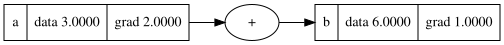

In [391]:
a=value(3.0, label='a')
b=a+a; b.label='b'
b.backward()
draw_dot(b)

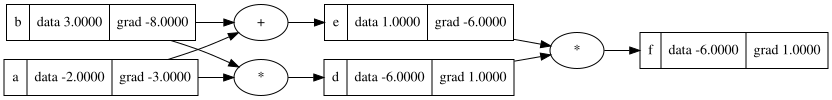

In [392]:
a=value(-2.0, label='a')
b=value(3.0, label='b')
d=a*b; d.label='d'
e=a+b; e.label='e'
f=d*e; f.label='f'
f.backward()

draw_dot(f)

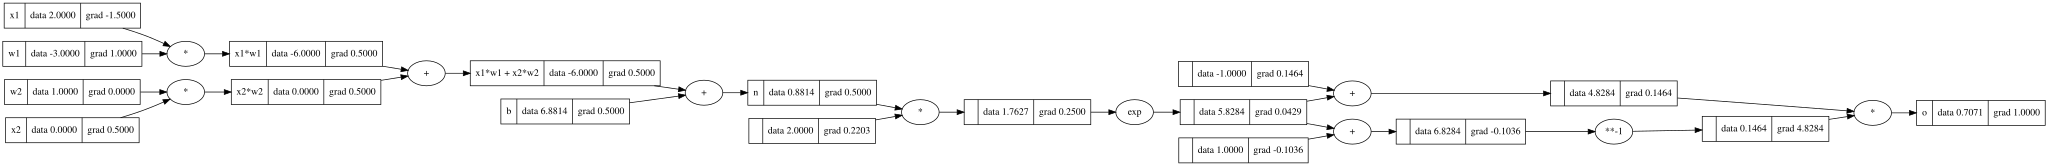

In [393]:
# inputs x1,x2
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')
# weights w1,w2
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')
# bias of the neuron
b = value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
# Changed 2*n to n*2 to avoid the TypeError
e = (n * 2).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

what we're expecting to see is

number 1: the same result here so the forward pass works and

number 2: because of that
mathematical equivalence we expect to see the same backward pass and the same gradients on these leaf nodes so thesegradients should be identical

# DOING THE SAME IN PYTORCH WITH TENSORS

In [394]:
import torch
import random

In [395]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [396]:
class Neuron:

  def __init__(self, nin): #nin - number of inputs into the neuron
    self.w = [value(random.uniform(-1,1)) for _ in range(nin)] #weight - random number b/w -1 & 1
    self.b = value(random.uniform(-1,1)) #and a bias that contrls the overall 'trigger happiness' of this neuron

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # zip takes two iterators & it creates a new iterator that iterates over the tuples of the corresponding entries
    out = act.tanh()
    return out


  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self, nin, nout): #nout - no. of neurons in a layer
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
      # OR: return [p for neuron in self.neurons for p in neuron.parameters()]
      params=[]
      for neuron in self.neurons:
        ps=neuron.parameters()
        params.extend(ps)
      return params


class MLP:
  def __init__(self, nin, nouts): #nouts - multiple layers to build an MLP -> list of neurons in each layer
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


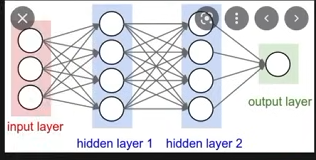

In [397]:
x=[2.0,3.0, -1.0]
n=MLP(3,[4,4,1])
n(x)  #3 independent valuation from 3 independent neurons

value(data=0.8777721843987005)

In [398]:
n.parameters()


[value(data=-0.6490193907344028),
 value(data=0.7120441809639371),
 value(data=-0.6820338146824636),
 value(data=-0.26826851819519404),
 value(data=0.4630811401773951),
 value(data=-0.4850121813060213),
 value(data=0.16308767407459035),
 value(data=0.25509104583355025),
 value(data=-0.32674614277404457),
 value(data=0.7269307253655366),
 value(data=0.8304008837637398),
 value(data=0.6461048425785543),
 value(data=0.9385899450175166),
 value(data=-0.139191943642194),
 value(data=0.44270307054904023),
 value(data=0.9997453372779783),
 value(data=0.6864313271171931),
 value(data=-0.1310552458284917),
 value(data=0.5536719513194337),
 value(data=-0.3470112461971355),
 value(data=-0.2603982133432048),
 value(data=0.6584005432572992),
 value(data=-0.16829169269401745),
 value(data=0.47982353855446735),
 value(data=0.6533607254979801),
 value(data=-0.22770271234593742),
 value(data=-0.2752652706388641),
 value(data=0.6175568338759772),
 value(data=-0.2373731129018164),
 value(data=0.473950942

In [399]:
len(n.parameters())

41

In [400]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred=[n(x) for x in xs]
ypred

[value(data=0.8777721843987005),
 value(data=-0.7394292214421511),
 value(data=0.3179029545509286),
 value(data=0.5827955325383656)]

In [401]:
#have to tune the output closer to [1.0, -1.0, -1.0, 1.0]

how do we make the neural net and how do we tune the weights to better predict the desired targets and the trick used in deep learning to achieve this is to calculate a single number that somehow measures the total performance of your neural net and we call this single number the loss

In [402]:
'''#mean square error loss
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss #we have to minimize it'''

value(data=1.993764534828922)

In [430]:
#actual training loop
for k in range(20):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)

0 0.003505961650256098
1 0.00348055276067064
2 0.0034555015559510826
3 0.0034308006055792256
4 0.0034064426823320086
5 0.003382420755401146
6 0.003358727983789937
7 0.003335357709973623
8 0.0033123034538117212
9 0.0032895589067004735
10 0.0032671179259543314
11 0.003244974529406532
12 0.0032231228902183844
13 0.0032015573318882884
14 0.0031802723234513482
15 0.0031592624748614916
16 0.0031385225325476036
17 0.00311804737513657
18 0.0030978320093355185
19 0.003077871565966844


In [431]:
ypred

[value(data=0.9853840611537663),
 value(data=-0.9829781392991501),
 value(data=-0.963554693555502),
 value(data=0.9646978500080023)]

In [419]:
loss.backward()

iterate for every p in n dot parameters so for all the 41 parameters in this neural net
we actually want to change p data slightly according to the gradient information
okay so dot dot to do here but this will be basically a tiny update
in this gradient descent scheme in gradient descent we are thinking of the
gradient as a vector pointing in the direction of increased
loss and so in gradient descent we are modifying

Why the Loss Explodes (The Gradient Accumulation Gotcha)
When calling .backward(), the autograd engine adds new gradients to existing .grad values instead of overwriting them. If gradients are not manually zeroed out before the next pass, they snowball. This causes your parameter updates to wildly overshoot the optimal values, flinging them across the error landscape and causing the loss to skyrocket.

The Fix: The Standard Training Loop
To prevent this, you must explicitly zero the gradients (p.grad = 0.0) before calculating the new backward pass.

In [424]:
#n.layers[0].neurons[0].w[0].data
'''out grad is +ve so it has increased for (0.01*p.grad)'''

'out grad is +ve so it has increased for (0.01*p.grad)'

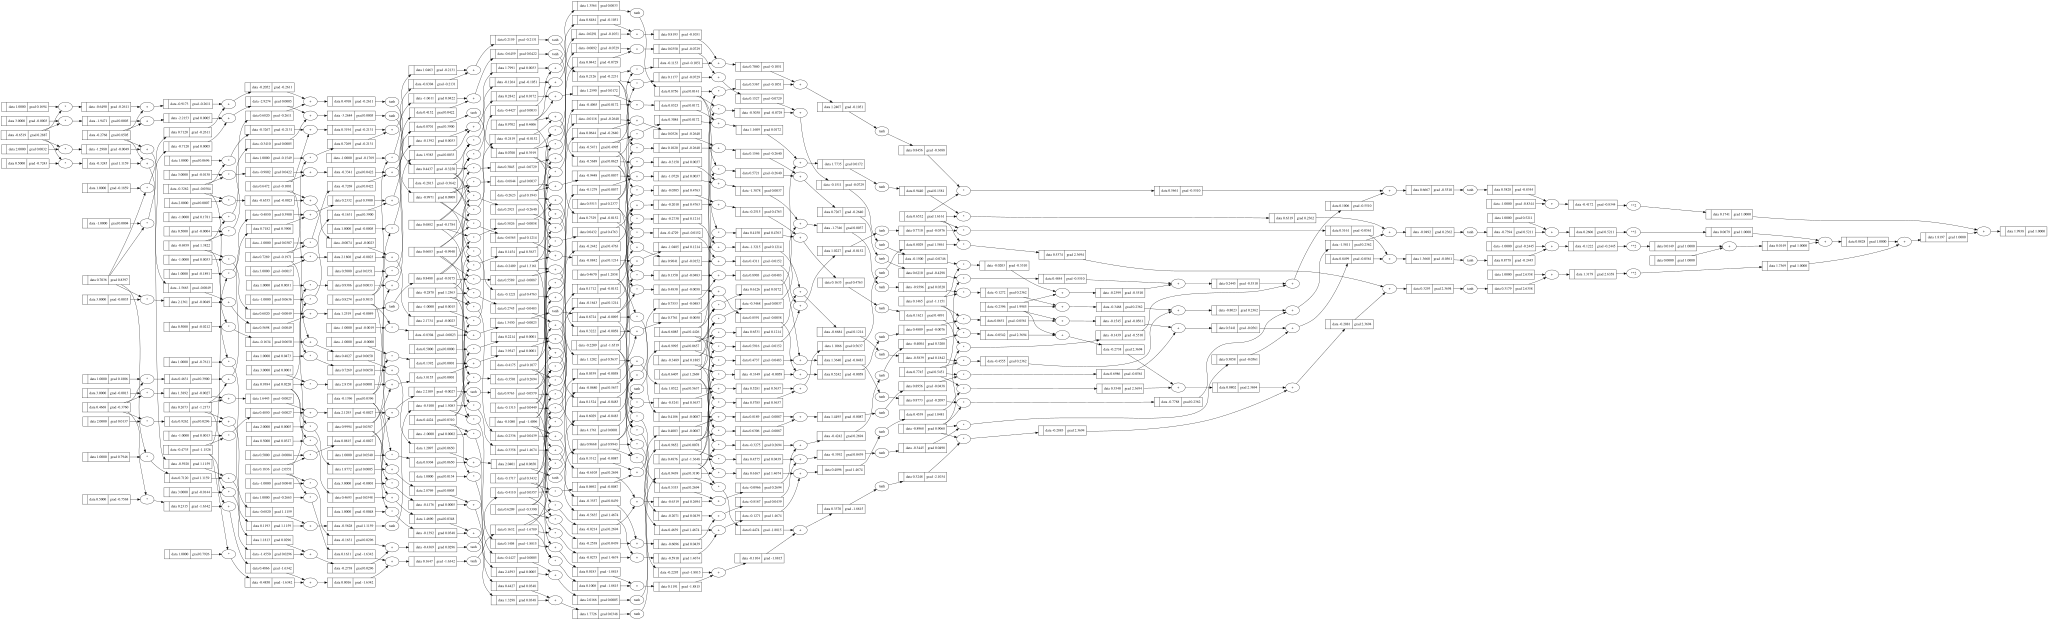

In [409]:
draw_dot(loss)